<a href="https://colab.research.google.com/github/Berk3459/Demand-Prediction/blob/main/sales_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#veri setini yükleme
df = pd.read_csv("/content/file_out.csv.zip")
df.head(5)

,Unnamed: 0,DocumentID,Date,SKU,Price,Discount,Customer,Quantity
0,0,716,2019-09-23,1039,381.78,67.37254,1,1.0
1,1,716,2019-09-23,853,593.22,0.00034,1,1.0
2,2,716,2019-09-23,862,423.73,-0.00119,1,1.0
3,3,716,2019-09-23,868,201.70,35.58814,1,1.0
4,4,716,2019-09-23,2313,345.76,61.01966,1,1.0


In [4]:
# Gereksiz sütunları kaldırma
df = df.drop("Unnamed: 0",axis = 1)

In [5]:
# Zaman serisi analizi için tarih indexi oluşturma
df["Date"] = pd.to_datetime(df["Date"])
df.set_index(df["Date"], inplace = True)
df.sort_index(inplace = True)

In [6]:
df = df.drop("Date",axis = 1)

In [8]:
# Kolonların isimlerini güncelleme
df.rename(columns = {"DocumentID" : "InvoiceID", "SKU" : "ProductID","Price" : "TotalSales", "Customer" : "CustomerID"},inplace = True)

# Zaman Serisi Modelleri
**Zaman serisi ayrıştırma**

zaman serisi modeli kurmadan önce veri setini ayrıştırarak daha doğru tahmin modelleri kurabiliriz ve daha doğru kararlar verebiliriz

In [9]:
# Zaman serisi veri seti
ts = df.groupby('Date')['TotalSales'].sum().to_frame()
ts.head()

,TotalSales
Date,
2019-01-01,635.593220
2019-01-02,27614.008475
2019-01-03,25399.456609
2019-01-04,23814.415086
2019-01-05,15722.511525


In [10]:
ts.head()

,TotalSales
Date,
2019-01-01,635.593220
2019-01-02,27614.008475
2019-01-03,25399.456609
2019-01-04,23814.415086
2019-01-05,15722.511525


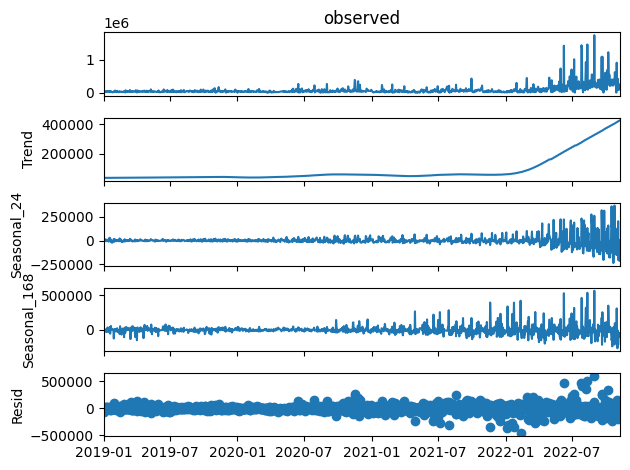

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose,MSTL

res = MSTL(ts, periods=(24, 24*7)).fit()
res.plot()
plt.tight_layout()
plt.show()

Bu sonuçlardan hareketle 2019-2022 yılları arasında satışların durağan trende ilerlediğini ve 2022 yılının başından itibaren trendin pozitif yönde artışa geçtiğini gözlemliyoruz.Ek olarak güünlük ve haftalık mevsimselliğin olduğunu yani satışların belirli bir periyod izlediğini görüyoruz

**Durağanlık testi**
ARIMA gibi modeller için veri setimizin durağan olması gerekir.
AdF testi yardımıyla veri setinin durağan olup olmadığına bakalım

In [12]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(ts["TotalSales"])

print(adf_test)
print('ADF Statistic: %f' % adf_test[0])
print('p-value: %f' % adf_test[1])

(np.float64(0.09835060346869938), np.float64(0.9659483015467684), 23, 1141, {'1%': np.float64(-3.4360941478268767), '5%': np.float64(-2.864076408006588), '10%': np.float64(-2.568120448620112)}, np.float64(29897.86082248247))
ADF Statistic: 0.098351
p-value: 0.965948


p değeri 0.05 den küçük olmadığından h0 hipotezini reddedemeyiz yani verimiz durağan değil. Veri setimizi durağanlaştırmak için diferansiyel alma yöntemini deneyelim.

In [13]:
ts = ts['TotalSales'].diff().dropna().to_frame()
ts

,TotalSales
Date,
2019-01-02,26978.415255
2019-01-03,-2214.551866
2019-01-04,-1585.041523
2019-01-05,-8091.903561
2019-01-07,36091.301382
...,...
2022-11-04,-203986.416782
2022-11-05,-136380.349488
2022-11-07,171156.083047


In [14]:
adf_test = adfuller(ts["TotalSales"])

print(adf_test)
print('ADF Statistic: %f' % adf_test[0])
print('p-value: %f' % adf_test[1])

(np.float64(-12.862135447482085), np.float64(5.083932332721321e-24), 23, 1140, {'1%': np.float64(-3.4360991979671205), '5%': np.float64(-2.864078635828568), '10%': np.float64(-2.568121635118498)}, np.float64(29870.200488002833))
ADF Statistic: -12.862135
p-value: 0.000000


görüldüğü gibi p değerimiz 0.05 den küçük çıktı.Yani artık veri setimiz durağan

# ARIMA MODELİ

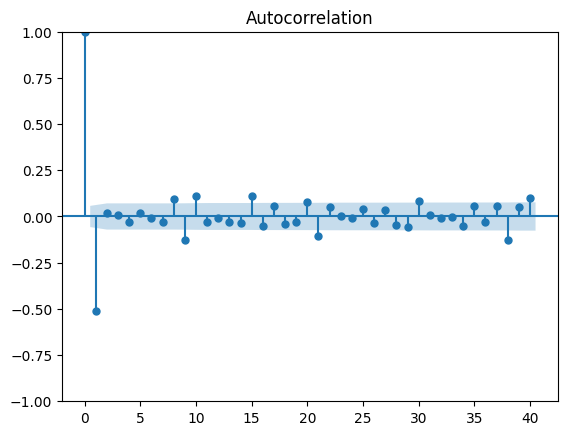

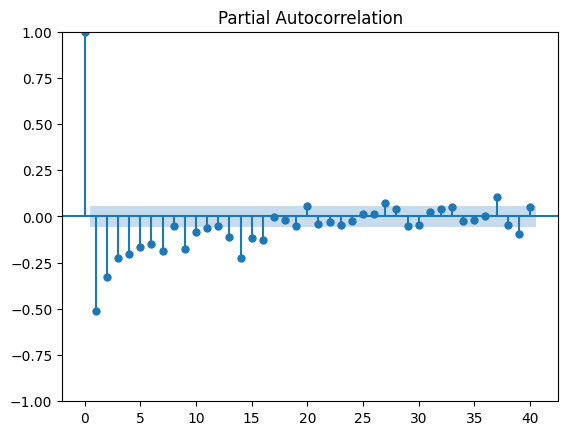

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ts['TotalSales'], lags=40)
plot_pacf(ts['TotalSales'], lags=40)
plt.show()

bu grafiklerden yola çıkarak gecikme değerlerini 1 olarak alabiliriz çünkü 1. gecikmelerde önemli sıçramalar görülüyor

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

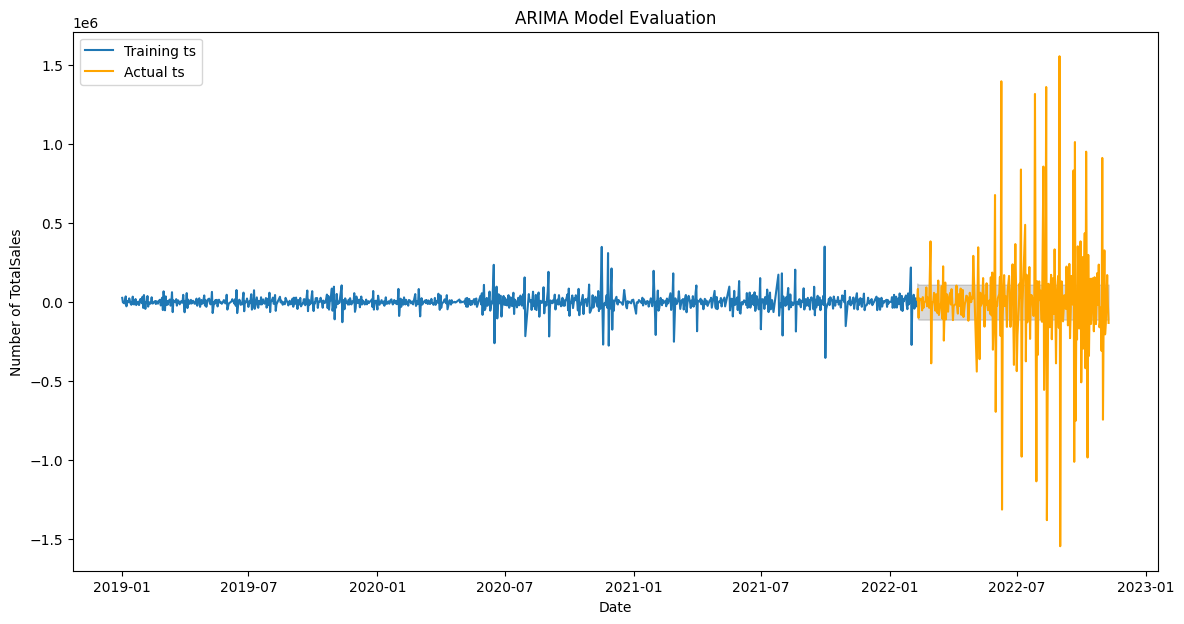

In [16]:
from statsmodels.tsa.arima.model import ARIMA

# veri setini train ve test olarak ayıralım
train_size = int(len(ts) * 0.8)
train, test = ts[0:train_size], ts[train_size:len(ts)]

# ARIMA modelini oluşturalım
model_train = ARIMA(train['TotalSales'], order=(1, 0, 1))
model_train_fit = model_train.fit()

# Tahmin değerleri
test_forecast = model_train_fit.get_forecast(steps=len(test))
test_forecast_series = pd.Series(test_forecast.predicted_mean, index=test.index)



# grafik çizimi
plt.figure(figsize=(14,7))
plt.plot(train['TotalSales'], label='Training ts')
plt.plot(test['TotalSales'], label='Actual ts', color='orange')

plt.fill_between(test.index,
                 test_forecast.conf_int().iloc[:, 0],
                 test_forecast.conf_int().iloc[:, 1],
                 color='k', alpha=.15)
plt.title('ARIMA Model Evaluation')
plt.xlabel('Date')
plt.ylabel('Number of TotalSales')
plt.legend()
plt.show()

**Verimizi normalize ettiğimiz için bu sonuçlar yanıltıcı olabilir şimdi bir LSTM model kurarak daha doğru sonuçlar elde etmeye çalışalım**

#LSTM

In [17]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras import Sequential
from keras import layers
from keras.models import Model
from keras.optimizers import Adam
from keras.layers import LSTM, Dropout, Dense, Flatten

In [18]:
df = df.groupby('Date').sum()
df = df[['TotalSales']]
df.head()

,TotalSales
Date,
2019-01-01,635.593220
2019-01-02,27614.008475
2019-01-03,25399.456609
2019-01-04,23814.415086
2019-01-05,15722.511525


In [19]:
data = df[['TotalSales']]
# veri setini numpy arraya çevirelim
dataset = data.values
training_data_len = int(np.ceil( len(dataset) * .95 ))
dataset

array([[   635.59322 ],
       [ 27614.008475],
       [ 25399.456609],
       ...,
       [255089.621184],
       [239127.687289],
       [107591.940678]])

In [20]:
# veriyi scale edelim
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.00036255],
       [0.01575141],
       [0.0144882 ],
       ...,
       [0.14550663],
       [0.13640173],
       [0.06137193]])

In [21]:
# train datası oluşturalım
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

# 60 günlük veriyi eğitm için kullanalım
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

# x_train ve y_train kısımlarını numpy arrayına çevirelim
x_train, y_train = np.array(x_train), np.array(y_train)

# modelimizi oluşturmak için veriyi reshape edelim
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_train.shape

[array([0.00036255, 0.01575141, 0.0144882 , 0.01358407, 0.00896834,
       0.02955531, 0.01440328, 0.0113906 , 0.01589761, 0.01565628,
       0.02927118, 0.02350081, 0.01395289, 0.01205661, 0.03176703,
       0.02470287, 0.01632563, 0.02748889, 0.01667298, 0.01282627,
       0.01269375, 0.01452704, 0.00382235, 0.01526759, 0.01707816,
       0.01312941, 0.03255314, 0.01154677, 0.03703993, 0.01267155,
       0.0125346 , 0.00960378, 0.03147577, 0.01520512, 0.01543112,
       0.00952857, 0.00915625, 0.02656724, 0.0216666 , 0.0170256 ,
       0.01586792, 0.01976838, 0.01277473, 0.01564096, 0.01538288,
       0.00970203, 0.01393448, 0.02267041, 0.01073414, 0.01481953,
       0.03063011, 0.00202127, 0.04091859, 0.01145455, 0.03214224,
       0.02149187, 0.02587987, 0.01680045, 0.02042337, 0.02981662])]
[np.float64(0.01701455836742419)]

[array([0.00036255, 0.01575141, 0.0144882 , 0.01358407, 0.00896834,
       0.02955531, 0.01440328, 0.0113906 , 0.01589761, 0.01565628,
       0.02927118, 0.02

(1047, 60, 1)

In [22]:
# LSTM modelimizi oluşturalım
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))


model.compile(optimizer='adam', loss='mean_squared_error')


model.fit(x_train, y_train, batch_size=1, epochs=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 53s 47ms/step - loss: 0.0035


In [23]:
# test datasını oluşturalım

test_data = scaled_data[training_data_len - 60: , :]

x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# veriyi numpy arrayına dönüştürelim
x_test = np.array(x_test)

# veriyi reshape edelim
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# tahmin değerlerini oluşturalım
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# RMSE değerleriyle modeli değerlendirelim
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 346ms/step


np.float64(260541.4402177404)

/tmp/ipython-input-4184554953.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


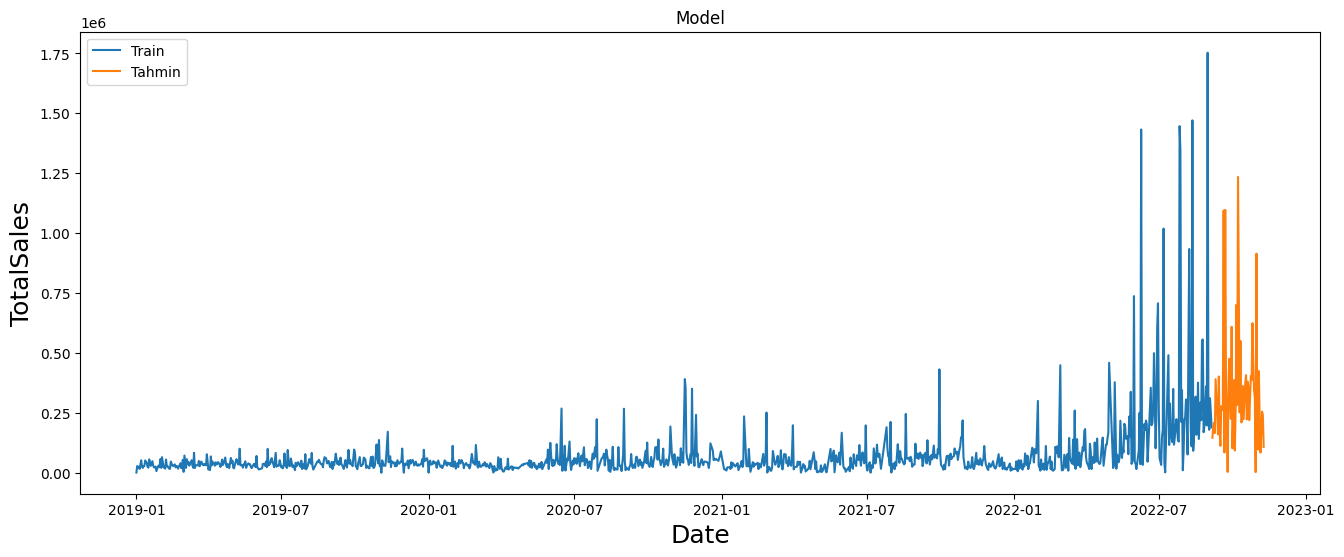

In [24]:
import matplotlib.pyplot as plt

train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions

plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('TotalSales', fontsize=18)
plt.plot(train['TotalSales'])
plt.plot(valid[['TotalSales',]])
plt.legend(['Train', 'Tahmin',], loc='upper left')
plt.show()